Approximate maximum at point: [2.292407326623354, 2.319860047010367] with value: 58.4316061305085
Algorithm converged at point: [2.292407326623354, 2.319860047010367] with value: 54.91574041344596


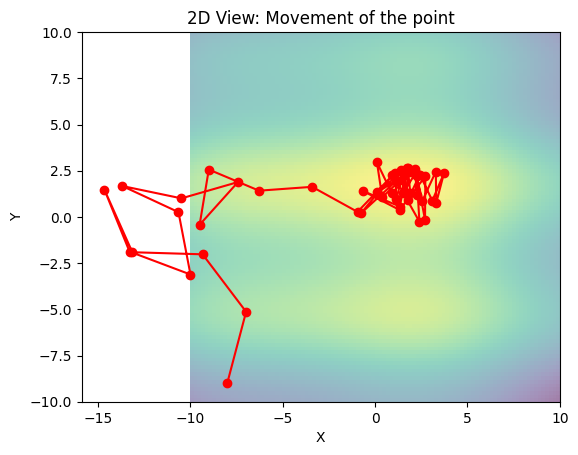

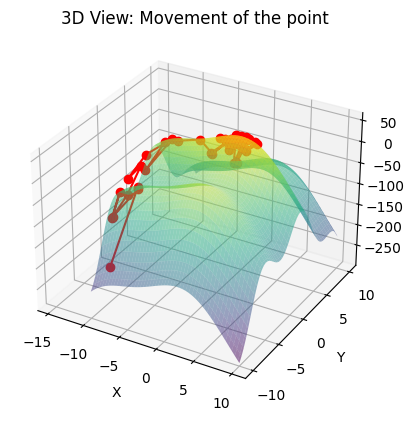

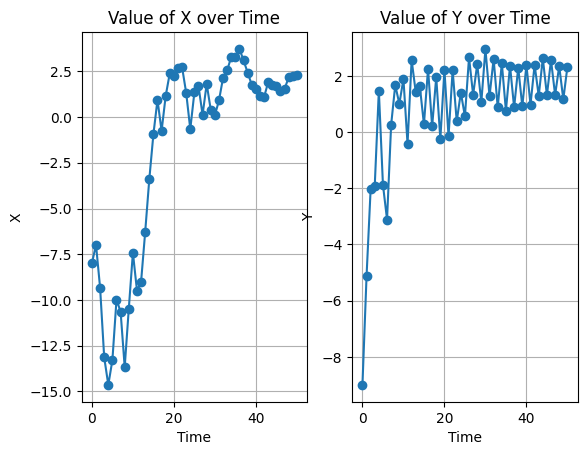

In [272]:
# 1. Import Relevant Libraries
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 2. Declare Constants and Variables
start_x = -8
start_y = -9

offset_x1 = 0
offset_y1 = 0.85
offset_x2 = 0.7
offset_y2 = -0.5
offset_x3 = -0.5
offset_y3 = -0.7

pos1 = [start_x+offset_x1, start_y+offset_y1]
pos2 = [start_x+offset_x2, start_y+offset_y2]
pos3 = [start_x+offset_x3, start_y+offset_y3]

max_iter = 50
step_size = 4
k = 1 
initial_temp = 10
cooling_rate = 0.975
min_temp = 0.08

# 3. Function to Define Surface
def f(x, y):
    return -0.985 * x ** 2 - 1.3 * x - 1.56 * y ** 2 + 0.25 * y + 15.9*np.sin(.452*x) + 33.8*np.sin(0.81*y) + 25

def slope_finder(pos1, pos2, pos3):  
    # Finds the magnitude based slopes
    poss1 = np.array([*pos1,f(pos1[0],pos1[1])])
    poss2 = np.array([*pos2,f(pos2[0],pos2[1])])
    poss3 = np.array([*pos3,f(pos3[0],pos3[1])])

    # Calculate vectors R12 and R13
    R12 = poss2 - poss1
    R13 = poss3 - poss1
   
    # Calculate the cross product of R12 and R13 - the normal vector
    Nx , Ny, _ = np.cross(R12, R13)
    angle = np.arctan2(Ny, Nx) #+ np.pi
    #print('The slope Nx is ', Nx,'The Ny is ', Ny, 'angle: ', angle )
    
    # Checking this an oldschool way for sanity's sake
#     slopex = (f(pos2[0],pos2[1]) - f(pos1[0],pos1[1]))/0.5
#     slopey = (f(pos3[0],pos3[1]) - f(pos1[0],pos1[1]))/0.5
#     angle2 = np.arctan2(slopey, slopex)
#     print('The slope_x is ', slopex,'The slopey is ', slopey, 'angle: ', angle2 )
#     print()
    return Nx, Ny, angle

# 4. Initialization

current_solution = [start_x, start_y]
current_value = f(start_x, start_y)

best_solution = current_solution
best_value = current_value

temperature = initial_temp
current_step_size = step_size

x_path = [start_x]
y_path = [start_y]

x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

# 5. Main Loop

for iteration in range(max_iter):
    
    angle_add = (np.exp(k*1.421*random.uniform(0,1)) - 1)*np.sign(random.uniform(-1, 1))
    #print()
    #print('Angle add',angle_add)
    
    
    Nx, Ny, angle = slope_finder(pos1, pos2, pos3)

    angle_step = angle + angle_add
    
    current_solution[0] += np.cos(angle_step)*current_step_size
    current_solution[1] += np.sin(angle_step)*current_step_size
    
    #current_solution = [x_path, y_path]
    
    pos1 = [current_solution[0]+offset_x1, current_solution[1]+offset_y1]
    pos2 = [current_solution[0]+offset_x2, current_solution[1]+offset_y2]
    pos3 = [current_solution[0]+offset_x3, current_solution[1]+offset_y3]
    
    
    current_value = f(current_solution[0],current_solution[1])

    if current_value > best_value:
        best_solution = current_solution
        best_value = current_value

    x_path.append(current_solution[0])
    y_path.append(current_solution[1])
    temperature *= cooling_rate
    current_step_size = current_step_size * cooling_rate
    k *= cooling_rate

    if temperature < min_temp:
        temperature = min_temp

# 6. Visualize Results
print(f"Approximate maximum at point: {best_solution} with value: {best_value}")
print(f"Algorithm converged at point: {current_solution} with value: {current_value}")

# 2D Visualization
plt.figure()
plt.imshow(Z, extent=[-10, 10, -10, 10], origin='lower', cmap='viridis', alpha=0.5)
plt.plot(x_path, y_path, 'r-o')
plt.title("2D View: Movement of the point")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# 3D Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
z_path = [f(x, y) for x, y in zip(x_path, y_path)]
ax.plot(x_path, y_path, z_path, 'r-o')
ax.set_title("3D View: Movement of the point")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

# Plot x and y vs time
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(x_path, '-o')
ax1.set_title("Value of X over Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("X")
ax1.grid(True)

ax2.plot(y_path, '-o')
ax2.set_title("Value of Y over Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Y")
ax2.grid(True)

plt.show()
